In [3]:
import pandas as pd
import plotly_express as px
import plotly.graph_objects as go

In [4]:
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv(r"C:\Dataset\shopping_behavior_updated.csv")

In [4]:
df.shape

(3900, 10)

In [120]:
#Khi vẽ biểu đồ cột:
#+ thông tin về trục x
#+  thông tin về trục y

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer ID            3900 non-null   int64  
 1   Age                    3900 non-null   int64  
 2   Gender                 3900 non-null   object 
 3   Item Purchased         3900 non-null   object 
 4   Category               3900 non-null   object 
 5   Purchase Amount (USD)  3900 non-null   int64  
 6   Location               3900 non-null   object 
 7   Unnamed: 7             0 non-null      float64
 8   Color                  3900 non-null   object 
 9   Season                 3900 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 304.8+ KB


In [17]:
df1=df.groupby('Area').count()
df1

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season
Area,,,,,,,,,
East,2274,2274,2274,2274,2274,2274,2274,2274,2274
West,869,869,869,869,869,869,869,869,869


In [87]:
df2=(df['Area'] == 'East')
df2

0        True
1        True
2        True
3        True
4       False
        ...  
3895     True
3896     True
3897    False
3898     True
3899    False
Name: Area, Length: 3900, dtype: bool

In [18]:
df1['Area']=['East','West']
df1

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season,Area
Area,,,,,,,,,,
East,2274,2274,2274,2274,2274,2274,2274,2274,2274,East
West,869,869,869,869,869,869,869,869,869,West


In [42]:
A=df1.dropna()

In [46]:
df1

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season,Area
Area,,,,,,,,,,
East,2274,2274,2274,2274,2274,2274,2274,2274,2274,East
Error,757,757,757,757,757,757,757,757,757,Error
West,869,869,869,869,869,869,869,869,869,West


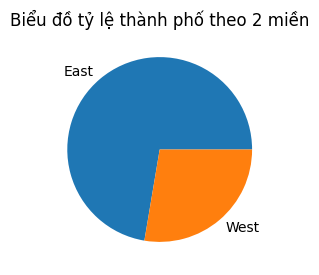

In [35]:
fig = plt.figure(figsize =(5, 3))
plt.pie(df1['Location'], # Giá trị của các nhãn
       labels = df1['Area'] # Danh sách các nhãn
)

# show plot
plt.title("Biểu đồ tỷ lệ thành phố theo 2 miền")
plt.show()


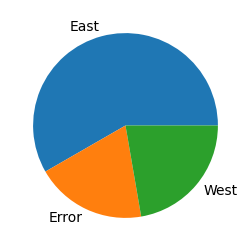

In [48]:
fig = plt.figure(figsize =(5, 3))
plt.pie(df1['Lo'], # Giá trị của các nhãn
       labels = df1['Area'] # Danh sách các nhãn
)

# show plot
plt.show()

In [100]:
df.to_csv(r"C:\Dataset\shopping_behavior_updated_Area.csv")

In [6]:
df['Location']

0            Kentucky
1               Maine
2       Massachusetts
3        Rhode Island
4              Oregon
            ...      
3895         Virginia
3896             Iowa
3897       New Jersey
3898        Minnesota
3899       California
Name: Location, Length: 3900, dtype: object

In [6]:
West=['Washington','Montana','North Dakota','Oregon',
      'Idaho','Wyoming','South Dakota','Nevada','Utah','Colorado','Kansas','Nebraska',"California",'Arizona','New Mexico','Texas','Oklahoma']
East=['Alabama','Arkansas','Connecticut','Delaware','Florida',
      'Georgia','Illinois','Indiana','Iowa','Kentucky','Louisiana',
      'Maine','Maryland','Massachusetts','Michigan','Minnesota','Mississippi',
      'Missouri','New Hampshire','New Jersey','New York','North Carolina','Ohio',
      'Pennsylvania','Rhode Island','South Carolina','Tennessee','Vermont','Virginia','West Virginia','Wisconsin']
df['Location'] = df['Location'].str.strip()
df['Area']=''
for i in range (df.shape[0]):
    if df['Location'][i] in East:
        df['Area'][i]='East'
    elif df['Location'][i] in West:
        df['Area'][i]='West'
    else:
        df['Area'][i]='Other'

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6728\3117817635.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Area'][i]='East'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6728\3117817635.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Area'][i]='East'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6728\3117817635.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Area'][i]='East'
C:\Users\Admi

In [98]:
#Xoá các dòng dữ liệu Other
df.drop(df[df['Area'] == 'Other'].index, inplace = True)

In [64]:
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season,Area
0,1,55,Male,Blouse,Clothing,53,Kentucky,Gray,Winter,East
1,2,19,Male,Sweater,Clothing,64,Maine,Maroon,Winter,East
2,3,50,Male,Jeans,Clothing,73,Massachusetts,Maroon,Spring,East
3,4,21,Male,Sandals,Footwear,90,Rhode Island,Maroon,Spring,East
4,5,45,Male,Blouse,Clothing,49,Oregon,Turquoise,Spring,West
5,6,46,Male,Sneakers,Footwear,20,Wyoming,White,Summer,West
6,7,63,Male,Shirt,Clothing,85,Montana,Gray,Fall,West
7,8,27,Male,Shorts,Clothing,34,Louisiana,Charcoal,Winter,East
8,9,26,Male,Coat,Outerwear,97,West Virginia,Silver,Summer,East
9,10,57,Male,Handbag,Accessories,31,Missouri,Pink,Spring,East


In [66]:
df1=df[df['Item Purchased']=='Dress']
df1

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season,Area
13,14,65,Male,Dress,Clothing,51,New Hampshire,Violet,Spring,East
17,18,53,Male,Dress,Clothing,38,Mississippi,Lavender,Winter,East
29,30,31,Male,Dress,Clothing,48,Wyoming,Black,Fall,West
31,32,33,Male,Dress,Clothing,79,West Virginia,Brown,Winter,East
38,39,29,Male,Dress,Clothing,37,Florida,Red,Winter,East
...,...,...,...,...,...,...,...,...,...,...
3814,3815,45,Female,Dress,Clothing,95,Michigan,Orange,Winter,East
3838,3839,47,Female,Dress,Clothing,25,Rhode Island,Green,Summer,East
3868,3869,18,Female,Dress,Clothing,29,Maryland,Magenta,Winter,East
3889,3890,57,Female,Dress,Clothing,65,Alaska,Yellow,Spring,Other


In [67]:
df1.groupby('Gender').count()

,Customer ID,Age,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season,Area
Gender,,,,,,,,,
Female,52,52,52,52,52,52,52,52,52
Male,114,114,114,114,114,114,114,114,114


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3763 entries, 0 to 3899
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Customer ID            3763 non-null   object
 1   Age                    3763 non-null   int64 
 2   Gender                 3763 non-null   object
 3   Item Purchased         3763 non-null   object
 4   Category               3763 non-null   object
 5   Purchase Amount (USD)  3763 non-null   int64 
 6   Location               3763 non-null   object
 7   Color                  3763 non-null   object
 8   Season                 3763 non-null   object
 9   Area                   3763 non-null   object
dtypes: int64(2), object(8)
memory usage: 323.4+ KB


In [77]:
df.describe()

,Age,Purchase Amount (USD)
count,3900.000000,3900.000000
mean,44.068462,59.764359
std,15.207589,23.685392
min,18.000000,20.000000
25%,31.000000,39.000000
50%,44.000000,60.000000
75%,57.000000,81.000000
max,70.000000,100.000000


In [15]:
season1=go.Figure(data=go.Violin(y=df['Age'],box_visible=True,line_color='black',
                                 meanline_visible=True,fillcolor='skyblue',opacity=0.6,
                                 x0='Biểu đồ thống kê độ tuổi của khách hàng'))
season1.update_layout(yaxis_zeroline=False)
season1.show()
season2=go.Figure(data=go.Violin(y=df['Purchase Amount (USD)'],box_visible=True,line_color='black',
                                 meanline_visible=True,fillcolor='skyblue',opacity=0.6,
                                 x0='Biểu đồ thống kê giá trị các đơn hàng'))
season1.update_layout(yaxis_zeroline=False)
season2.show()

In [7]:
#del df["Promo Code Used"]
del df['Unnamed: 7']

In [8]:
df["Customer ID"]=df["Customer ID"].astype("str")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Customer ID            3900 non-null   object
 1   Age                    3900 non-null   int64 
 2   Gender                 3900 non-null   object
 3   Item Purchased         3900 non-null   object
 4   Category               3900 non-null   object
 5   Purchase Amount (USD)  3900 non-null   int64 
 6   Location               3900 non-null   object
 7   Color                  3900 non-null   object
 8   Season                 3900 non-null   object
 9   Area                   3900 non-null   object
dtypes: int64(2), object(8)
memory usage: 304.8+ KB


In [55]:
season1=go.Figure(data=go.Violin(y=df['Age'],x=df['Area'],box_visible=True,line_color='black',
                                 meanline_visible=True,fillcolor='skyblue',opacity=0.6,
                                 ))
season1.update_layout(yaxis_zeroline=False)
season1.show()

In [85]:
season1=go.Figure(data=go.Violin(y=df['Previous Purchases'],x=df['Gender'],box_visible=True,line_color='black',
                                 meanline_visible=True,fillcolor='skyblue',opacity=0.6,
                                 ))
season1.update_layout(yaxis_zeroline=False)
season1.show()

In [96]:
from pandas import DataFrame

In [111]:
df1=(df['Gender'],df['Previous Purchases'])

In [112]:
df1

(0         Male
 1         Male
 2         Male
 3         Male
 4         Male
          ...  
 3895    Female
 3896    Female
 3897    Female
 3898    Female
 3899    Female
 Name: Gender, Length: 3900, dtype: object,
 0       14
 1        2
 2       23
 3       49
 4       31
         ..
 3895    32
 3896    41
 3897    24
 3898    24
 3899    33
 Name: Previous Purchases, Length: 3900, dtype: int64)